# Student Employability Analysis and Placement Prediction


## 1. Objective
The goal of this project is to analyze student data and identify factors that influence placement outcomes. Later, a machine learning model will be developed to predict whether a student is likely to be placed. 

In [1]:
#Imprting libraries
import pandas as pd
import numpy as np
import seaborn as sns

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("placementdata.csv")
df.head()


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


## 3. Dataset Overview 
The dataset contains academic, skilled-based, and extracurricular information about students along with their placement status.

In [3]:
df.shape

(10000, 12)

In [4]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 937.6 KB


In [6]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


## 4. Data Quality Assessment

In [7]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

#### Dataset Overview
The Dataset contains 10,000 student records and 12 columns.<br>
There are no missing values were found.<br>
The target column is Placement_Status, which indicates whether a student was placed or not placed. <br>
The dataset contains academic, skill-based, and training-related attributes such as CGPA, internships, projects, aptitude scores, and soft skills ratings. Most features are numerical.<br>

## 5. Target Variable Analysis
### Placement Status Distribution

In [9]:
df["PlacementStatus"].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

#### Observation 
The dataset contains 10,000 student records.<br>
- 5,803 students were not placed.<br>
- 4,197 students were placed.<br>
The target value is moderately inbalanced, with approximately 58% of students not placed and 42% placed. However, the imbalance is not severe enough to prevent building machine learning model.


In [10]:
df["PlacementStatus"].value_counts(normalize=True)*100

PlacementStatus
NotPlaced    58.03
Placed       41.97
Name: proportion, dtype: float64

 
Visualizing the number of placed and non-placed students.

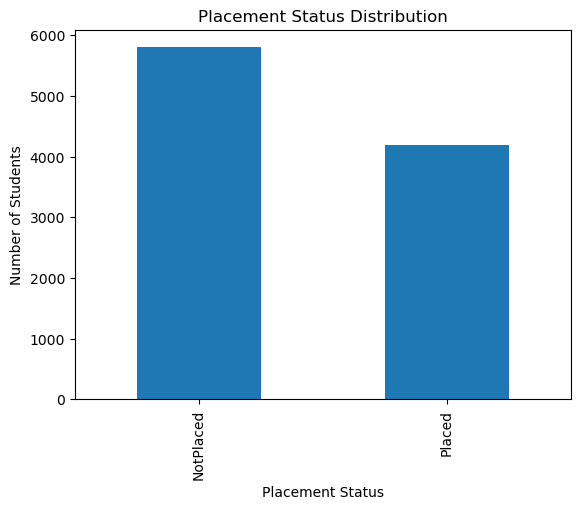

In [11]:
import matplotlib.pyplot as plt
df["PlacementStatus"].value_counts().plot(kind="bar")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

## 6. Feature-wise Analysis
### 6.1 CGPA Analysis
Analyzing the relationship between CGPA and placement status.

In [12]:
df.groupby("PlacementStatus")["CGPA"].mean()

PlacementStatus
NotPlaced    7.467672
Placed       8.016488
Name: CGPA, dtype: float64

#### Observation 
Students who were placed have a higher average CGPA (8.02) compared to students who were not placed (7.47). <br>
This suggests that academic performance may have a positive influence on placement outcomes.

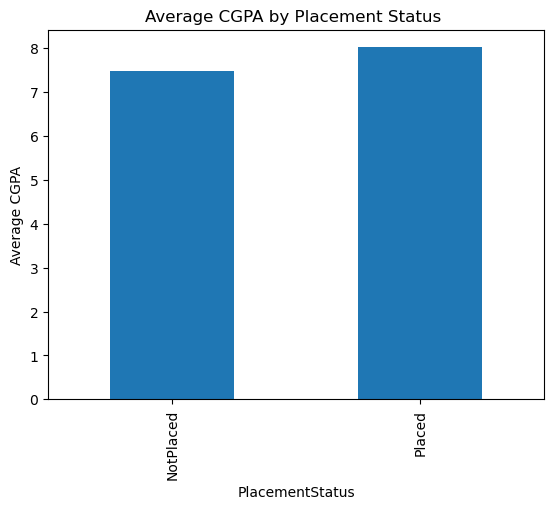

In [13]:
df.groupby("PlacementStatus")["CGPA"].mean().plot(kind="bar")
plt.title("Average CGPA by Placement Status ")
plt.ylabel("Average CGPA")
plt.show()

### 6.2 Internship Analysis

In [14]:
df.groupby("PlacementStatus")["Internships"].mean()

PlacementStatus
NotPlaced    0.901775
Placed       1.253038
Name: Internships, dtype: float64

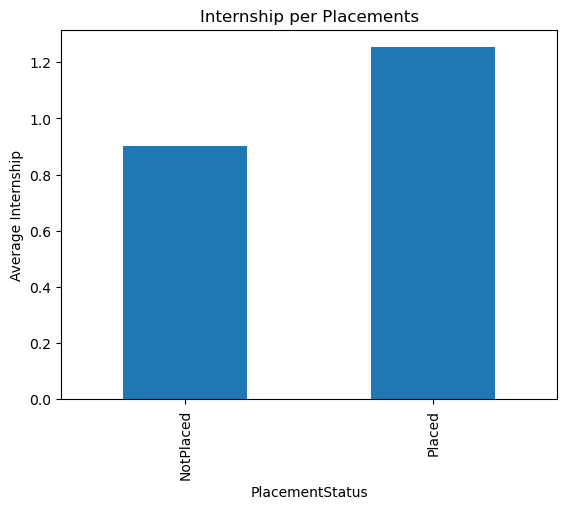

In [15]:
df.groupby("PlacementStatus")["Internships"].mean().plot(kind="bar")
plt.title("Internship per Placements")
plt.ylabel("Average Internship")
plt.show()

## 7. Univariate Analysis
Univariate analysis focuses on examining one variable at a time to understand its distribution, spread, central tendency, and presence of outliers. This step helps identify unusual patterns and provides insights into the characteristics of individual features before studying relationships between multiple variables.

- Understand the distribution of each feature.
- Detect skewness in the data.
- Identify potential outliers.
- Understand the variability of numerical features.
- Prepare the dataset for machine learning.

### 7.1 Distribution of CGPA 
CGPA is one of the most influential academic indicators in student placement prediction. Analyzing its distribution helps us understand the academic performance of students and identify whether the values are normally distributed, skewed, or contain any unusual observations.

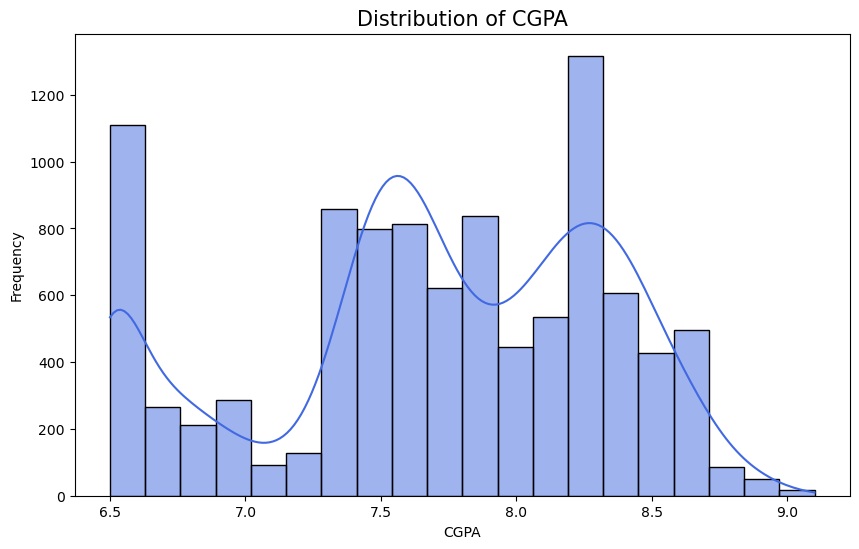

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='CGPA',
    kde="True",
    bins=20,
    color='royalblue'
)
plt.title("Distribution of CGPA", fontsize=15)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

#### Observation

- The CGPA values range approximately from 6.5 to 9.1, indicating realistic academic scores.
- Most students have CGPA values between 7.4 and 8.5, suggesting that the majority of students have good academic performance.
- The distribution is not perfectly normal and appears to have multiple regions where values are concentrated.
- Overall, the CGPA feature appears to be well-distributed and suitable for further exploratory analysis and machine learning.
  

### 7.2 Outlier Detection of CGPA 
After understanding the distribution of CGPA, it is important to identify whether the dataset contains any outliers. Outliers are observations that differ significantly from the majority of the data and may affect statistical analysis and machine learning models.
A box plot provides a simple visual representation of the spread of data and helps identify potential outliers using the Interquartile Range (IQR) method [IQR=Q3-Q1].

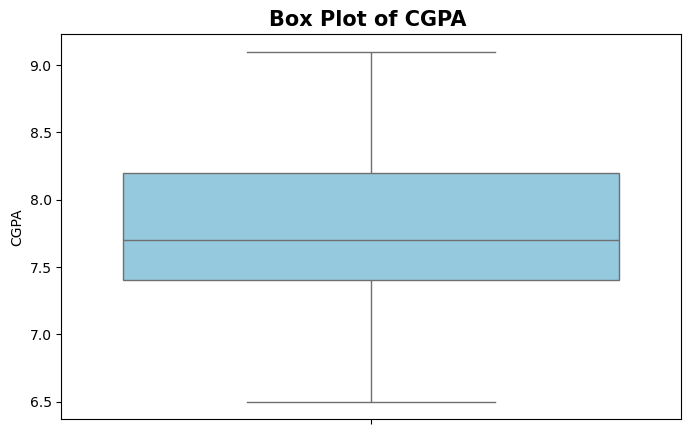

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df['CGPA'],
    color='skyblue'
    )
plt.title("Box Plot of CGPA ", fontsize=15, fontweight='bold')
plt.ylabel("CGPA")
plt.show()